# 08 · Other Distributions and the Central Limit Theorem

Not everything is a bell curve. Clicks, sales, survival, waiting times and income all follow other shapes. In this notebook we meet the most useful ones, learn how to check whether data is normal, and finish with the **central limit theorem**, the reason the bell curve still shows up everywhere.

**What you will learn here**

1. PMF vs PDF
2. Bernoulli distribution (one yes/no trial)
3. Binomial distribution (many yes/no trials)
4. Poisson distribution (counts of rare events)
5. Log-normal distribution and the log transform
6. Pareto distribution and the 80-20 rule
7. Q-Q plot: checking if data is normal
8. Central limit theorem

## Datasets used

| Dataset | Used for | Source | Licence |
|---|---|---|---|
| Titanic (`data/titanic.csv`) | Bernoulli, binomial | [seaborn-data](https://github.com/mwaskom/seaborn-data) | Historical records, free for teaching |
| Prussian horse kicks (`data/horse_kicks.csv`) | Poisson | [Rdatasets](https://vincentarelbundock.github.io/Rdatasets/csv/pscl/prussian.csv), R package `pscl`, from von Bortkiewicz (1898) | Historical data, public domain. `pscl` is GPL |
| Tips (`data/tips.csv`) | Log-normal, Q-Q plot | [seaborn-data](https://github.com/mwaskom/seaborn-data) | Teaching dataset |
| Cookie Cats (`data/cookie_cats.csv`) | Pareto, central limit theorem | [Kaggle / DataCamp](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing) mobile game data, GitHub mirror | Shared publicly for learning |

**Horse kicks columns:** `y` = number of soldiers killed by a horse kick in one army corps in one year, `year` = 1875 to 1894 (stored as 75 to 94), `corp` = army corps.

**Cookie Cats columns used here:** `sum_gamerounds` = number of game rounds a player played in the first two weeks after installing.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

titanic = pd.read_csv("../data/titanic.csv")
kicks = pd.read_csv("../data/horse_kicks.csv")
tips = pd.read_csv("../data/tips.csv")
cookie = pd.read_csv("../data/cookie_cats.csv")

---
## 1. PMF vs PDF

| | PMF (probability mass function) | PDF (probability density function) |
|---|---|---|
| For | **Discrete** values (0, 1, 2, ...) | **Continuous** values (any decimal) |
| Height of the bar/curve | Is a probability: P(X = 3) | Is a density, not a probability |
| Probability comes from | Reading the bar | The area under the curve |
| Examples | Bernoulli, binomial, Poisson | Normal, log-normal, Pareto |

For continuous data, P(height is exactly 175.000... cm) = 0. We can only ask about ranges, like P(170 < height < 180).

---
## 2. Bernoulli distribution

> **Theory.** One single trial with two outcomes: success (1) or failure (0).

- P(X = 1) = p
- P(X = 0) = q = 1 − p

Examples: one coin toss, one visitor buys or not, one email is spam or not, one passenger survives or not.

**Formula**

$$P(X = k) = p^k (1 - p)^{1 - k}, \quad k \in \{0, 1\}$$

$$\text{mean} = p, \qquad \text{variance} = p(1 - p)$$

**Small example:** pick one random Titanic passenger. p = P(survived) = 342 / 891 = 0.384

**By hand:** mean = 0.384, variance = 0.384 × 0.616 = **0.237**

In [2]:
p = titanic["survived"].mean()

print(f"p (survived) = {p:.3f},  q = {1 - p:.3f}")
print(f"variance by formula     : {p * (1 - p):.3f}")
print(f"variance of the 0/1 data: {titanic['survived'].var(ddof=0):.3f}")

p (survived) = 0.384,  q = 0.616
variance by formula     : 0.237
variance of the 0/1 data: 0.237


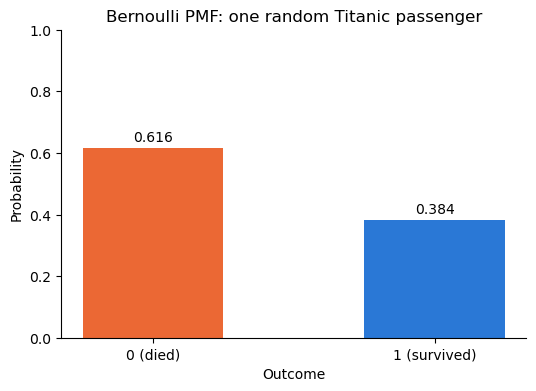

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["0 (died)", "1 (survived)"], [1 - p, p], color=[ORANGE, BLUE], width=0.5)
for i, value in enumerate([1 - p, p]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")
ax.set_title("Bernoulli PMF: one random Titanic passenger")
ax.set_xlabel("Outcome")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
plt.show()

Two bars only. That is the whole Bernoulli distribution. Conversion rates in A/B tests are Bernoulli data: each visitor converts (1) or not (0).

---
## 3. Binomial distribution

> **Theory.** Repeat a Bernoulli trial **n times**, independently, with the same p, and count the successes. The count follows a binomial distribution, written B(n, p).

Examples: heads in 10 tosses, buyers among 1,000 visitors, survivors among 5 random passengers.

**Formula**

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$

$$\text{mean} = np, \qquad \text{variance} = np(1 - p)$$

The $\binom{n}{k}$ part (combinations, notebook 04) counts the number of ways to place k successes among n trials.

**Small example:** pick 5 random passengers. What is the chance that **exactly 3** survived?

**By hand** (p = 0.384)

$$P(X = 3) = \binom{5}{3} \cdot 0.384^3 \cdot 0.616^2 = 10 \times 0.0566 \times 0.3795 = 0.215$$

In [4]:
n, k = 5, 3
# docs: https://docs.python.org/3/library/math.html#math.comb
prob_by_hand = math.comb(n, k) * p ** k * (1 - p) ** (n - k)
print(f"By formula: {prob_by_hand:.4f}")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
print(f"scipy     : {stats.binom.pmf(k, n, p):.4f}")

By formula: 0.2147
scipy     : 0.2147


Now let's check it against the **real data**: pick 5 real passengers many times and count survivors. (We pick with replacement so every pick has the same p, like the binomial assumes.)

In [5]:
np.random.seed(0)
survived = titanic["survived"].to_numpy()
repeats = 20_000

survivors_in_group = np.array([np.random.choice(survived, size=5).sum() for _ in range(repeats)])

real_share = pd.Series(survivors_in_group).value_counts(normalize=True).sort_index()
model_share = pd.Series(stats.binom.pmf(range(6), 5, p), index=range(6))

comparison = pd.DataFrame({"from real data": real_share, "binomial model": model_share}).round(3)
comparison

,from real data,binomial model
0,0.083,0.089
1,0.278,0.277
2,0.346,0.345
3,0.217,0.215
4,0.067,0.067
5,0.009,0.008


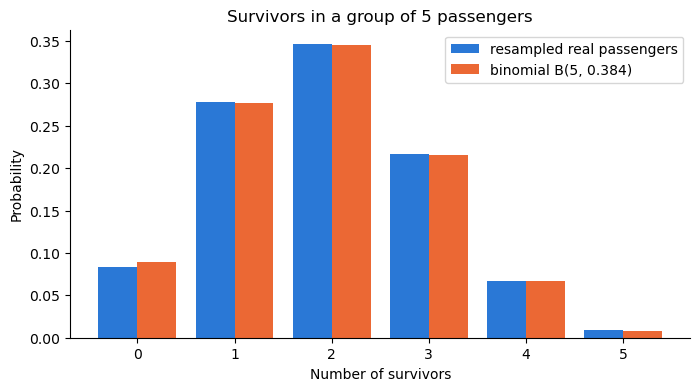

In [6]:
fig, ax = plt.subplots()
positions = np.arange(6)
ax.bar(positions - 0.2, comparison["from real data"], width=0.4, color=BLUE, label="resampled real passengers")
ax.bar(positions + 0.2, comparison["binomial model"], width=0.4, color=ORANGE, label="binomial B(5, 0.384)")
ax.set_title("Survivors in a group of 5 passengers")
ax.set_xlabel("Number of survivors")
ax.set_ylabel("Probability")
ax.legend()
plt.show()

The model and the real data match very closely. Most often, 1 or 2 of the 5 survive.

---
## 4. Poisson distribution

> **Theory.** Counts how many times a **rare event** happens in a fixed interval (of time, space, etc.), when events happen independently at a constant average rate λ ("lambda").

Examples: customers arriving per minute, server errors per hour, typos per page, goals in a football match.

**Formula**

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

$$\text{mean} = \lambda, \qquad \text{variance} = \lambda$$

A quick check for Poisson data: **mean ≈ variance**.

### The most famous Poisson dataset

In 1898, the statistician Ladislaus von Bortkiewicz counted soldiers killed by horse kicks in 14 Prussian army corps over 20 years (280 corps-years). A rare, random event: perfect for Poisson.

In [7]:
counts = kicks["y"].value_counts().sort_index()
print("deaths per corps-year -> how many corps-years")
print(counts.to_string())
print()
print(f"mean     = {kicks['y'].mean():.3f}")
print(f"variance = {kicks['y'].var():.3f}")

deaths per corps-year -> how many corps-years
y
0    144
1     91
2     32
3     11
4      2

mean     = 0.700
variance = 0.763


Mean 0.70 and variance 0.76 are close, a good sign for Poisson. So λ = 0.7 deaths per corps per year.

**By hand:** how many corps-years should have **0 deaths**?

$$P(X = 0) = \frac{0.7^0 \, e^{-0.7}}{0!} = e^{-0.7} = 0.4966$$

Expected count = 280 × 0.4966 = **139**. Observed: **144**.

And for 1 death: $P(X = 1) = 0.7 \times e^{-0.7} = 0.3476$ → 280 × 0.3476 = **97**. Observed: **91**.

In [8]:
lam = kicks["y"].mean()
k_values = np.arange(0, 5)

table = pd.DataFrame({
    "deaths": k_values,
    "observed": counts.reindex(k_values, fill_value=0).values,
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html
    "Poisson expected": (len(kicks) * stats.poisson.pmf(k_values, lam)).round(1),
})
table

,deaths,observed,Poisson expected
0,0,144,139.0
1,1,91,97.3
2,2,32,34.1
3,3,11,7.9
4,4,2,1.4


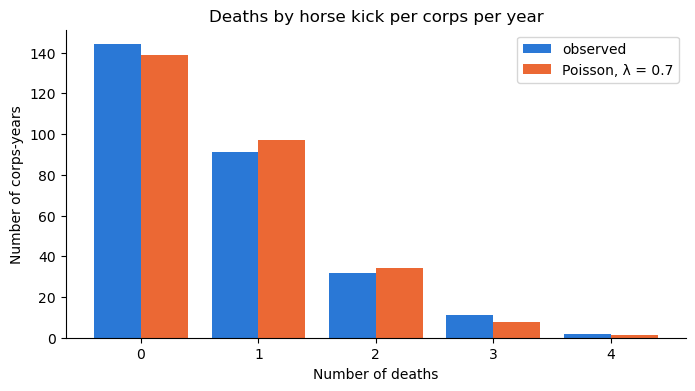

In [9]:
fig, ax = plt.subplots()
ax.bar(table["deaths"] - 0.2, table["observed"], width=0.4, color=BLUE, label="observed")
ax.bar(table["deaths"] + 0.2, table["Poisson expected"], width=0.4, color=ORANGE, label="Poisson, λ = 0.7")
ax.set_title("Deaths by horse kick per corps per year")
ax.set_xlabel("Number of deaths")
ax.set_ylabel("Number of corps-years")
ax.legend()
plt.show()

A one-number model (λ = 0.7) predicts the whole table almost perfectly. That's why Poisson is used for things like planning call-centre staff or server capacity.

Read more: [Poisson distribution (Wikipedia)](https://en.wikipedia.org/wiki/Poisson_distribution), which tells the horse-kick story in its history section

---
## 5. Log-normal distribution

> **Theory.** A variable X is **log-normal** if log(X) is normal. Its histogram has a long right tail: many small values, a few very large ones. It can only take positive values.

Examples: incomes, house prices, restaurant bills, time spent on a website, length of comments.

**Relation**

$$X \sim \text{LogNormal} \iff Y = \ln(X) \sim \text{Normal}$$

**Why do we need it?** Many tests assume normal data. If the data is log-normal, taking the log turns it into normal data, and those tests work again. It also makes "times bigger" effects easier to read.

**Small example by hand:** bills 10, 20, 40, 80 dollars. Each one is double the previous one, so on the original scale the gaps grow (10, 20, 40). After ln: 2.30, 3.00, 3.69, 4.38, the gaps are equal (0.69 each). The log turns "multiply" into "add".

In [10]:
bills = np.array([10, 20, 40, 80])
print("ln(bills):", np.log(bills).round(2))
print("gaps     :", np.diff(np.log(bills)).round(2))

ln(bills): [2.3  3.   3.69 4.38]
gaps     : [0.69 0.69 0.69]


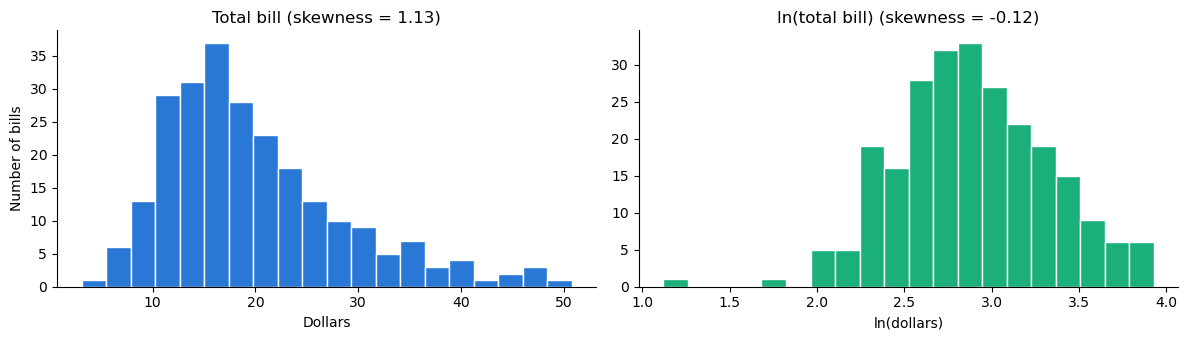

In [11]:
bill = tips["total_bill"]
log_bill = np.log(bill)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(bill, bins=20, color=BLUE, edgecolor="white")
axes[0].set_title(f"Total bill (skewness = {bill.skew():.2f})")
axes[0].set_xlabel("Dollars")
axes[0].set_ylabel("Number of bills")
axes[1].hist(log_bill, bins=20, color=GREEN, edgecolor="white")
axes[1].set_title(f"ln(total bill) (skewness = {log_bill.skew():.2f})")
axes[1].set_xlabel("ln(dollars)")
plt.tight_layout()
plt.show()

The bills are right-skewed (1.13). After the log, the shape is close to a symmetric bell (skewness −0.12). The bills behave roughly like a log-normal variable.

---
## 6. Pareto distribution and the 80-20 rule

> **Theory.** The Pareto distribution (a **power law**) has an even heavier tail than the log-normal. A small group accounts for most of the total. The famous version is the **80-20 rule**: about 80% of the effect comes from 20% of the causes.

Examples: 20% of customers bring 80% of revenue, 20% of bugs cause 80% of crashes, a few players play most of the rounds in a mobile game.

**Formula** (PDF, for $x \ge x_m$)

$$f(x) = \frac{\alpha \, x_m^{\alpha}}{x^{\alpha + 1}}$$

$x_m$ is the minimum value, $\alpha$ controls how heavy the tail is (smaller α = more extreme). α ≈ 1.16 gives exactly the 80-20 rule.

### Real data: rounds played in a mobile game

In [12]:
rounds = cookie["sum_gamerounds"]
print(rounds.describe().round(1))

count    90189.0
mean        51.9
std        195.1
min          0.0
25%          5.0
50%         16.0
75%         51.0
max      49854.0
Name: sum_gamerounds, dtype: float64


Mean 52 but median 16, and one player with 49,854 rounds. Very heavy tail. Let's check the "80-20" idea: what share of all rounds was played by the top 20% of players?

In [13]:
sorted_rounds = rounds.sort_values(ascending=False).to_numpy()
top_20_count = int(len(sorted_rounds) * 0.20)

share_top_20 = sorted_rounds[:top_20_count].sum() / sorted_rounds.sum()
print(f"Top 20% of players played {share_top_20:.0%} of all rounds")

Top 20% of players played 74% of all rounds


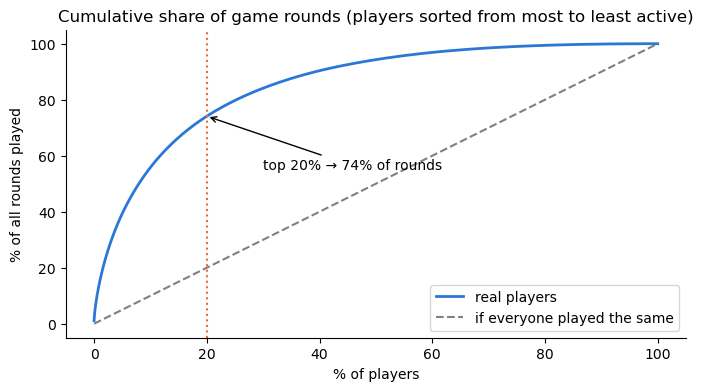

In [14]:
cumulative_share = np.cumsum(sorted_rounds) / sorted_rounds.sum()
player_share = np.arange(1, len(sorted_rounds) + 1) / len(sorted_rounds)

fig, ax = plt.subplots()
ax.plot(player_share * 100, cumulative_share * 100, color=BLUE, linewidth=2, label="real players")
ax.plot([0, 100], [0, 100], color="grey", linestyle="--", label="if everyone played the same")
ax.axvline(20, color=ORANGE, linestyle=":")
ax.annotate(f"top 20% → {share_top_20:.0%} of rounds", xy=(20, share_top_20 * 100), xytext=(30, 55),
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Cumulative share of game rounds (players sorted from most to least active)")
ax.set_xlabel("% of players")
ax.set_ylabel("% of all rounds played")
ax.legend(loc="lower right")
plt.show()

The top 20% of players played about 74% of all rounds. Not exactly 80-20, but the same idea. For a game company this matters: the average player (52 rounds) doesn't exist. Most players play a little, a few play a lot, and the mean is pulled up by the heavy users.

---
## 7. Q-Q plot: is my data normal?

> **Theory.** A **quantile-quantile (Q-Q) plot** compares the quantiles of our data with the quantiles a perfect normal distribution would have.

- Points on the straight line → data is close to normal
- Points curving away at the ends → skewed or heavy tails

It's more precise than eyeballing a histogram, especially in the tails.

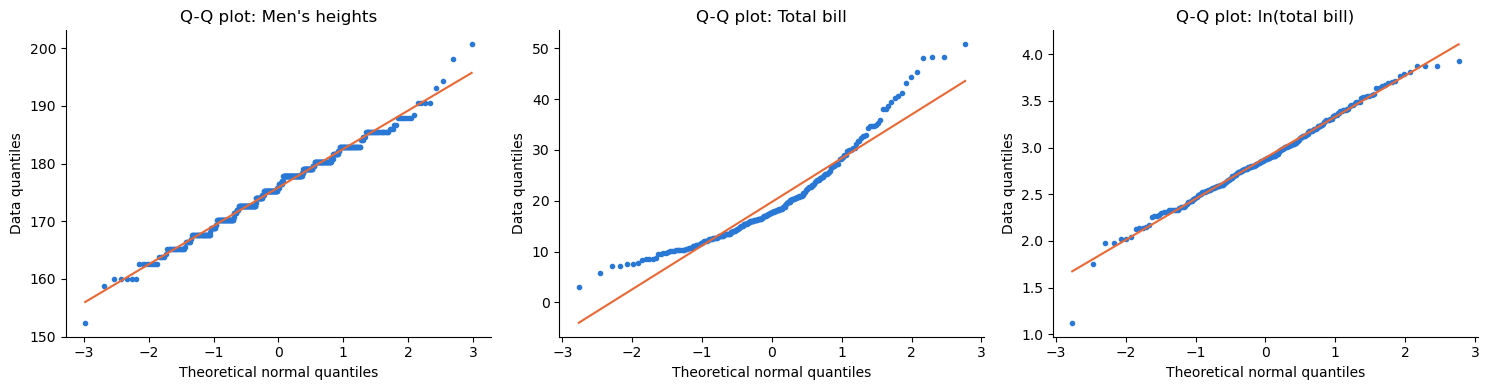

In [15]:
galton = pd.read_csv("../data/galton_heights.csv")
men_height = galton.loc[galton["gender"] == "male", "childHeight"] * 2.54

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in [
    (axes[0], men_height, "Men's heights"),
    (axes[1], bill, "Total bill"),
    (axes[2], log_bill, "ln(total bill)"),
]:
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html
    stats.probplot(data, dist="norm", plot=ax)
    ax.get_lines()[0].set_color(BLUE)
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[1].set_color(ORANGE)
    ax.set_title(f"Q-Q plot: {title}")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Data quantiles")
plt.tight_layout()
plt.show()

- **Heights:** points sit on the line, so close to normal.
- **Total bill:** the points bend upward at the right end. The big bills are bigger than a normal curve would allow (right skew).
- **ln(total bill):** much straighter. The log transform fixed most of the skew.

### Other transformations

| Transformation | When |
|---|---|
| log(x) | Right-skewed, positive values (money, durations) |
| log(x + 1) | Same, but data contains zeros (counts) |
| √x | Mild right skew, counts |
| Box-Cox | Lets the data pick the best power automatically (positive values only) |

In [16]:
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html
boxcox_bill, best_lambda = stats.boxcox(bill)

print(f"skewness original : {bill.skew():.3f}")
print(f"skewness log      : {log_bill.skew():.3f}")
print(f"skewness sqrt     : {np.sqrt(bill).skew():.3f}")
print(f"skewness Box-Cox  : {pd.Series(boxcox_bill).skew():.3f}   (best lambda = {best_lambda:.2f})")

skewness original : 1.133
skewness log      : -0.116
skewness sqrt     : 0.566
skewness Box-Cox  : 0.003   (best lambda = 0.08)


Box-Cox found the power that removes the skew almost completely. Its λ of about 0.08 is close to 0, and λ = 0 is exactly the log transform, which is why the log worked well too.

---
## 8. Central limit theorem (CLT)

> **Theory.**
>
> Take many random samples of size n from **any** population (with a finite variance). Compute the mean of each sample. If n is big enough, the **sample means** follow a normal distribution, centred at the population mean μ, with standard deviation σ / √n.

The data itself doesn't have to be normal. Only the **means** become normal.

**Formula**

$$\bar{X} \approx N\left(\mu, \ \frac{\sigma}{\sqrt{n}}\right) \quad \text{for large } n$$

$\sigma / \sqrt{n}$ is the **standard error** we used in the z-test and confidence intervals. This is where the √n comes from.

**Why do we need it?** It's the reason z-tests, t-tests and confidence intervals work on skewed real data like revenue or session time, as long as the sample is large enough. Every A/B test on averages relies on it.

Read more: [Central limit theorem (Wikipedia)](https://en.wikipedia.org/wiki/Central_limit_theorem) · [Seeing Theory: probability distributions and CLT](https://seeing-theory.brown.edu/probability-distributions/index.html)

### Experiment on very skewed data

Population: rounds played by 90,188 Cookie Cats players. I remove the one player with 49,854 rounds. They played nearly 50,000 rounds in two weeks, which is almost certainly a bot or a logging error, and it would make the variance meaningless.

Then: draw 5,000 samples of size n, compute each sample mean, and look at the shape of those means.

In [17]:
population = rounds[rounds < 49_854].to_numpy()
mu = population.mean()
sigma = population.std()
print(f"Population: N = {len(population):,}, mean = {mu:.2f}, sd = {sigma:.2f}, skewness = {stats.skew(population):.1f}")

Population: N = 90,188, mean = 51.32, sd = 102.68, skewness = 6.0


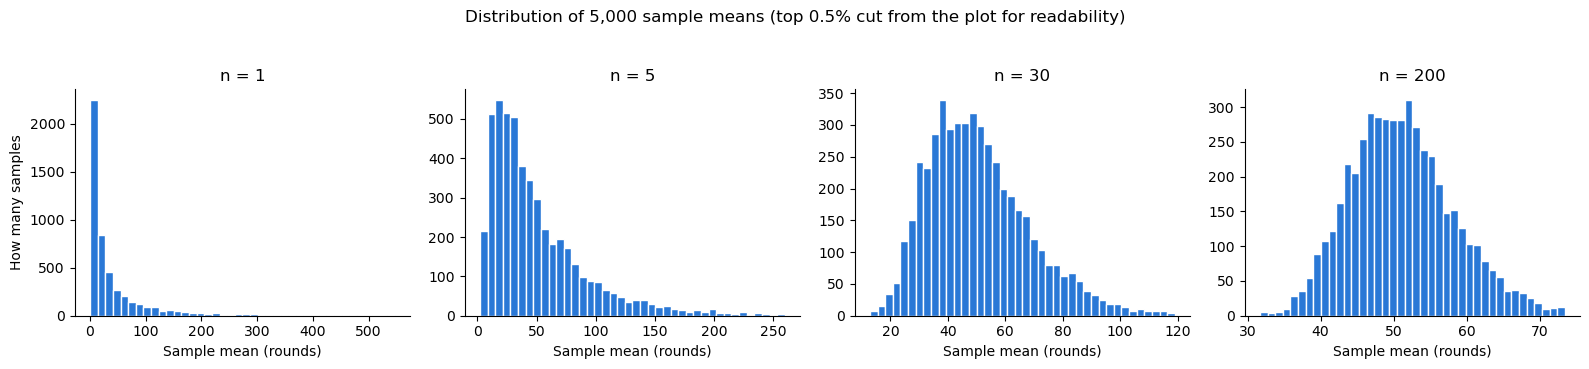

In [18]:
np.random.seed(42)
sample_sizes = [1, 5, 30, 200]
sample_means = {}
for n in sample_sizes:
    sample_means[n] = np.array([np.random.choice(population, size=n).mean() for _ in range(5000)])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, sample_sizes):
    means = sample_means[n]
    # docs: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html
    upper = np.percentile(means, 99.5)
    ax.hist(means[means <= upper], bins=40, color=BLUE, edgecolor="white")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample mean (rounds)")
axes[0].set_ylabel("How many samples")
fig.suptitle("Distribution of 5,000 sample means (top 0.5% cut from the plot for readability)", y=1.04)
plt.tight_layout()
plt.show()

- **n = 1:** each "mean" is just one player, so we see the raw skewed data.
- **n = 5:** still skewed.
- **n = 30:** much more bell-like, but a clear right tail is still there.
- **n = 200:** close to a bell curve, with only a slight right tail left.

For very skewed data like this, "n ≥ 30" is a minimum, not a guarantee. The more skewed the data, the bigger n must be.

### Does the standard error really equal σ / √n?

In [19]:
rows = []
for n in sample_sizes:
    rows.append({
        "n": n,
        "mean of sample means": sample_means[n].mean(),
        "sd of sample means (simulated)": sample_means[n].std(),
        "sigma / sqrt(n) (formula)": sigma / np.sqrt(n),
        "skewness of means": stats.skew(sample_means[n]),
    })
pd.DataFrame(rows).round(2)

,n,mean of sample means,sd of sample means (simulated),sigma / sqrt(n) (formula),skewness of means
0,1,50.32,97.28,102.68,4.98
1,5,51.51,46.23,45.92,2.73
2,30,51.15,18.70,18.75,1.08
3,200,51.25,7.32,7.26,0.52


> **Check:** Three things to notice:

1. The **mean of the sample means** is always about 51, the population mean.
2. The **spread** of the sample means matches σ / √n closely (small differences are simulation noise).
3. The **skewness** of the means drops from 5.0 to 0.5 as n grows: the shape moves towards normal. With data this skewed, it needs a few hundred values per sample to get really close.

This is the bridge between probability and inference: because of the CLT, we know how much a sample mean wobbles, so we can build confidence intervals and tests for it.

---
## Summary

| Distribution | Type | Parameters | Mean | Typical use |
|---|---|---|---|---|
| Bernoulli | discrete | p | p | One yes/no (click, conversion) |
| Binomial | discrete | n, p | np | Number of yes in n trials |
| Poisson | discrete | λ | λ | Rare events per interval |
| Normal | continuous | μ, σ | μ | Heights, errors, sample means |
| Log-normal | continuous | μ, σ of ln(X) | | Money, durations |
| Pareto | continuous | x_m, α | | Very unequal things (80-20) |

| Tool | What it does |
|---|---|
| Q-Q plot | Checks normality, points on the line = normal |
| log / √ / Box-Cox | Reduce right skew |
| CLT | Sample means become normal with sd σ / √n |

## What's next

In **09 · ANOVA** we compare the means of **three or more** groups at once with the F-test, working through the full calculation by hand.

## References and further reading

- [Seeing Theory](https://seeing-theory.brown.edu/) (interactive visual explanations, Brown University), chapter on probability distributions
- [Binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution) · [Log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution) · [Pareto distribution](https://en.wikipedia.org/wiki/Pareto_distribution) (Wikipedia)
- [Q-Q plot, Wikipedia](https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot) · [Power transform / Box-Cox, Wikipedia](https://en.wikipedia.org/wiki/Power_transform)
- [scipy `probplot`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html) · [scipy `boxcox`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html)